In [1]:
def projectDistZ(x1,x2,y1,y2,d12,z):
    mx = (x2-x1)/d12
    xProj = x1 + mx * z
    
    my = (y2-y1)/d12
    yProj = y1 + my * z
    
    return (xProj, yProj)

def get_theta_angles(x1, y1, x2, y2, d):
    import numpy as np
    thetaX = np.arctan((x2-x1)/d) #rad
    thetaY = np.arctan((y2-y1)/d) #rad
    return (thetaX, thetaY)

def file_loader(runs):
    from collections.abc import Iterable

    if not isinstance(runs, Iterable):
        runs = [runs]

    pos = []
    phs = []
    tmis = []
    qtots = []
    nclus = []
    info_pluss = []
    xinfos = []
    n_spill_list = []

    for run_number in runs:
        data_path = f'/eos/project/i/insulab-como/testBeam/TB_2025_06_T9_epBOOST/HDF5/run{run_number}.h5'
        with h5py.File(data_path, 'r', libver='latest', swmr=True) as hf:
            pos.append(np.array(hf['xpos']))
            phs.append(np.array(hf['digiPH']))
            tmis.append(np.array(hf['digiTime']))
            qtots.append(np.array(hf['qtot']))
            nclus.append(np.array(hf['nclu']))
            info_plus = np.array(hf['info_plus'])
            xinfo = np.array(hf['xinfo'])
            info_pluss.append(info_plus)
            xinfos.append(xinfo)

            n_spill = int(np.max(info_plus[:, 0]))
            n_spill_list.append(n_spill)
            print(f'Run {run_number} — N spill: {n_spill} — events: {len(hf["xpos"])} — evs/spill: {len(hf["xpos"]) / n_spill:.0f}')

    xpos = np.concatenate(pos, axis=0)
    ph = np.concatenate(phs, axis=0)
    tm = np.concatenate(tmis, axis=0)
    qtot = np.concatenate(qtots, axis=0)
    nclu = np.concatenate(nclus, axis=0)
    info_plus = np.concatenate(info_pluss, axis=0)
    xinfo = np.concatenate(xinfos, axis=0)

    logic_pos = (xpos[:, :6] > -1) & (xpos[:, :6] < 15)
    
    logic = logic_pos.all(axis = 1)
    xpos= xpos[logic]
    ph= ph[logic]
    tm= tm[logic]
    qtot= qtot[logic]
    nclu= nclu[logic]
    info_plus= info_plus[logic]
    xinfo= xinfo[logic]
    # Apply offsets
    xpos[:, 0] -= offset_x1
    xpos[:, 1] -= offset_y1
    xpos[:, 4] -= offset_x3
    xpos[:, 5] -= offset_y3

    x1 = xpos[:, 0]
    y1 = xpos[:, 1]
    x2 = xpos[:, 2]
    y2 = xpos[:, 3]
    x3 = xpos[:, 4]
    y3 = xpos[:, 5]

    Calibration = False
    if Calibration:
        q = -25.84
        m = 323.4
        ph[:, 2] = (ph[:, 2] - q) / m

    xcry, ycry = projectDistZ(x1, x2, y1, y2, d12, d1c)
    theta_x_in, theta_y_in = get_theta_angles(x1, y1, x2, y2, d12)
    theta_x_out, theta_y_out = get_theta_angles(xcry, ycry, x3, y3, dc3)

    ph_calo_photon = ph[:, 2]
    ph_cherry1 = ph[:, 0]

    total_spills = sum(n_spill_list)
    print(f"{runs} — TOTAL SPILLS: {total_spills} — TOTAL EVENTS: {len(x1)}")

    return xpos, x1, y1, x2, y2, x3, y3, xcry, ycry, ph_calo_photon, ph_cherry1, \
           theta_x_in, theta_y_in, theta_x_out, theta_y_out, tm, qtot, nclu, info_plus, xinfo


def canonical_type(typ):
    typ = typ.lower()
    if 'axis' in typ or 'aligned' in typ:
        return 'Axis'
    elif 'amorph' in typ:
        return 'Amorphous'
    elif 'conv' in typ:
        return 'Conventional'
    elif 'trans' in typ:
        return 'Transition'
    else:
        return 'Unknown'

def get_color(label):
    label = label.lower()  # per evitare distinzione maiuscole/minuscole
    if "axis" in label:
        return "tab:blue"
    elif "amorphous" in label:
        return "orange"
    elif "conventional" in label:
        return "darkslategrey"
    else:
        return "black"  # default color

In [9]:
import json
import numpy as np
import h5py
from collections import defaultdict
from collections.abc import Iterable
import matplotlib.pyplot as plt

# === Parametri di selezione ===
target_sample = "Hybrid"  # e.g., W12mm Hybrid 
target_energy = 2.86     # GeV: 2.86 or 6
CutTheta = True           # Applica taglio angolare
ifConventional = True     # Includi tipo 'conventional' indipendentemente dal sample
ifAmorphous = True       # Includi tipo 'amorphous' indipendentemente dal sample

# === OFFSET e DISTANZE ===
d12 = 330  # cm
d23 = 66.8
d1c = 330 + 53.2
dc3 = 10.7
d1calo = d1c + 779.2

offset_x1 = 0.107
offset_y1 = -2.21
offset_x3 = 0.484
offset_y3 = -2.053

# === CHAMBERS AND DECORATORS ===
range_chamber = ((0, 10), (0, 10))
bins2d = (100, 100)
mycmap = 'jet'

opt_hist = {'histtype': 'step', 'lw': 1.5, 'alpha': 0.8}
opts_2d = {"cmap": mycmap, "bins": bins2d}

# === LOGICAL THRESHOLDS ===
th_cherry1 = 20
th_cherry2 = 20

# === Caricamento file di configurazione ===
with open("run_config.json", "r") as f:
    run_config = json.load(f)

# === RAGGRUPPA PER TIPO (con sample ed energia selezionati) ===
group_by_type = defaultdict(list)
energies = {}
samples = {}
types = {}
x_cry_cuts = {}
y_cry_cuts = {}

for run_str, conf in run_config.items():
    try:
        sample = conf["sample"].strip().lower()
        typ = conf["type"].strip().lower()
        energy = float(conf["energy"])
        run = int(run_str)

        energy_match = abs(energy - target_energy) < 1e-3
        sample_match = sample == target_sample.lower()

        include = False
        if energy_match:
            if typ == "conventional" and ifConventional:
                include = True
            elif typ == "amorphous" and ifAmorphous and sample_match:
                include = True
            elif sample_match and typ not in ["conventional", "amorphous"]:
                include = True

        if include:
            group_by_type[typ].append(run)
            samples[run] = sample
            types[run] = typ
            energies[run] = energy
            x_cry_cuts[run] = conf["x_cry_cut"]
            y_cry_cuts[run] = conf["y_cry_cut"]

    except Exception as e:
        print(f"⚠️ Errore in run {run_str}: {e}")

# === Output per confronto ===
print(f"\n📊 Confronto tra 'type' per sample = '{target_sample}', energy = {target_energy:.2f} GeV")
for typ, runs in group_by_type.items():
    print(f"- Type: {typ:15} → {len(runs)} run(s): {runs}")



📊 Confronto tra 'type' per sample = 'Hybrid', energy = 2.86 GeV


In [10]:
# === CALCOLO THETA_CUT SOLO DAL PRIMO RUN PER GRUPPO ===
theta_crit_dict = {}
theta_cut_dict = {}

for runs in group_by_type.values():
    ref_run = runs[0]  # Usa solo il primo run come riferimento
    energy = energies[ref_run]
    theta_crit = np.sqrt(2 * 887 / (np.abs(energy) * 1e9))  # rad

    sample_str = samples[ref_run]
    type_str = types[ref_run]
    if "conventional" in sample_str or "conventional" in type_str:
        theta_cut = 1e11
    elif "amorphous" in sample_str or "amorphous" in type_str:
        theta_cut = 1e11
    else:
        # theta_cut = theta_crit/2 if CutTheta else 1e11
        theta_cut = theta_crit if CutTheta else 1e11

    for run in runs:
        theta_crit_dict[run] = theta_crit
        theta_cut_dict[run] = theta_cut

# === STAMPA RIASSUNTIVA ===
print("\n🔍 Tagli angolari (theta_cut):")
runs_flat = []
for runs in group_by_type.values():
    for run in runs:
        theta = theta_cut_dict[run]
        tc = theta_crit_dict[run]
        print(f"Run {run}: θ_cut (Radius)= {theta * 1e6:.2f} µrad, θ_Crit = {tc * 1e6:.2f} µrad")
        runs_flat.append(run)



🔍 Tagli angolari (theta_cut):



🔍 Analisi Type = conventional
Run 730247 — N spill: 710 — events: 76622 — evs/spill: 108
[730247] — TOTAL SPILLS: 710 — TOTAL EVENTS: 75721
Run 730247 -- w15mm -6.0GeV: Δx = 0.500 cm, Δy = 0.500 cm, Area = 0.250 cm²
events after cuts: 13602, discarded events : 82.04%


🔍 Analisi Type = axis
Run 730245 — N spill: 2860 — events: 274725 — evs/spill: 96
[730245] — TOTAL SPILLS: 2860 — TOTAL EVENTS: 271623
Run 730245 -- w12mm -6.0GeV: Δx = 0.500 cm, Δy = 0.500 cm, Area = 0.250 cm²
events after cuts: 47846, discarded events : 82.39%


🔍 Analisi Type = amorphous
Run 730224 — N spill: 1334 — events: 194507 — evs/spill: 146
[730224] — TOTAL SPILLS: 1334 — TOTAL EVENTS: 192340
Run 730224 -- w12mm -6.0GeV: Δx = 0.500 cm, Δy = 0.500 cm, Area = 0.250 cm²
events after cuts: 36209, discarded events : 81.17%



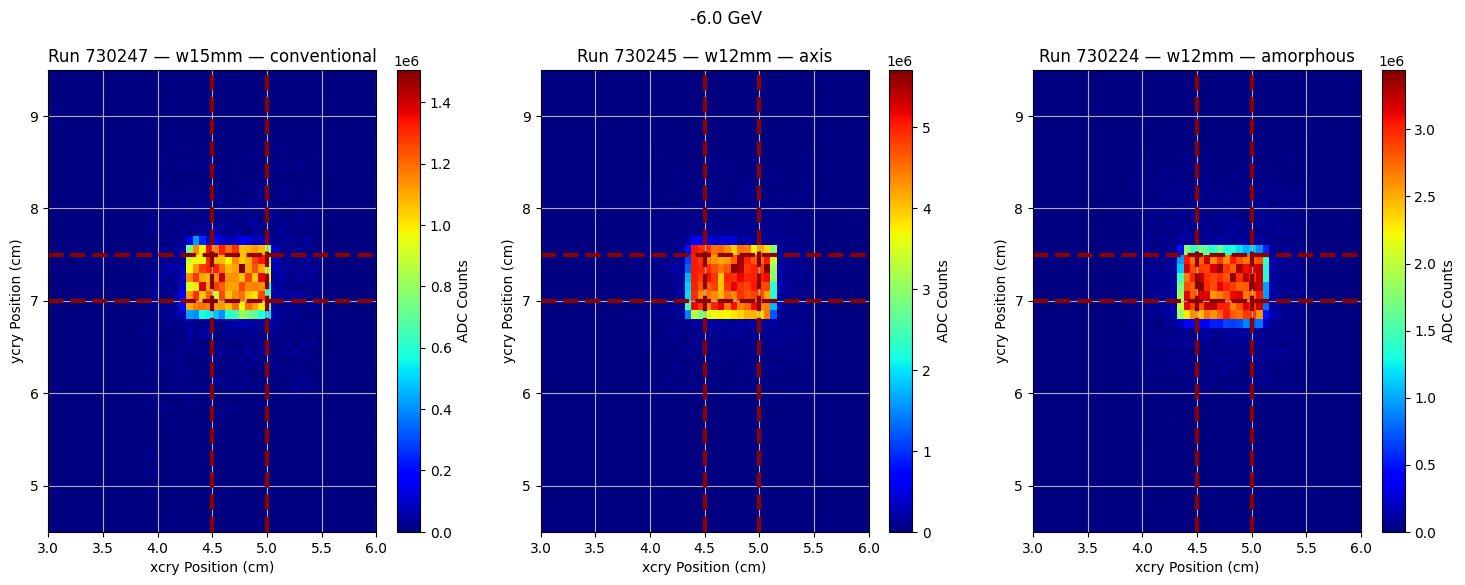

In [4]:
import matplotlib.pyplot as plt

n_types = len(group_by_type)
fig, ax = plt.subplots(1, n_types, figsize=(6 * n_types, 6), squeeze=False)
fig.suptitle(f' {energies[ref_run]} GeV')
ax = ax[0]  # flat access, so you can use ax[j]

for j, (typ, run) in enumerate(group_by_type.items()):
    print(f"\n🔍 Analisi Type = {typ}")
    (xpos, x1, y1, x2, y2, x3, y3, xcry, ycry, ph_calo_photon, ph_cherry1,
     theta_x_in, theta_y_in, theta_x_out, theta_y_out, tm, qtot, nclu,
     info_plus, xinfo) = file_loader(run)

    ref_run = run[0]  # 👈 usa il primo run per i parametri di configurazione

    # === Build selection mask ===
    mask = (
        (ph_cherry1 > th_cherry1) &
        ((theta_x_in**2 + theta_y_in**2) < (theta_cut**2)) &
        (nclu[:,0]>1)
    )

    # === Plot 2D histogram ===
    h = ax[j].hist2d(
        xcry[mask], ycry[mask],
        range=((3, 6), (4.5 ,9.5 )),
        weights=qtot[:, 0][mask],
        cmap=mycmap,
        bins=50
    )

    # === Decorations ===
    ax[j].set_title(f"Run {ref_run} — {samples[ref_run]} — {types[ref_run]}")
    ax[j].set_xlabel("xcry Position (cm)")
    ax[j].set_ylabel("ycry Position (cm)")
    ax[j].grid(True)

    # === Show selection box ===
    x_min, x_max = x_cry_cuts[ref_run]
    y_min, y_max = y_cry_cuts[ref_run]
    dx, dy = x_max - x_min, y_max - y_min
    ax[j].axvline(x=x_min, color='darkred', linestyle='--', lw=3)
    ax[j].axvline(x=x_max, color='darkred', linestyle='--', lw=3)
    ax[j].axhline(y=y_min, color='darkred', linestyle='--', lw=3)
    ax[j].axhline(y=y_max, color='darkred', linestyle='--', lw=3)

    # === Print area info ===
    print(f"Run {ref_run} -- {samples[ref_run]} {energies[ref_run]}GeV: Δx = {dx:.3f} cm, Δy = {dy:.3f} cm, Area = {dx * dy:.3f} cm²")
    print(f'events after cuts: {np.sum(mask)}, discarded events : {100*(1-np.sum(mask)/np.size(mask)):.2f}%\n')
    
    # === Add colorbar ===
    plt.colorbar(h[3], ax=ax[j], label='ADC Counts')
plt.show()

Run 730247 — N spill: 710 — events: 76622 — evs/spill: 108
[730247] — TOTAL SPILLS: 710 — TOTAL EVENTS: 75721
Run 730245 — N spill: 2860 — events: 274725 — evs/spill: 96
[730245] — TOTAL SPILLS: 2860 — TOTAL EVENTS: 271623
Run 730224 — N spill: 1334 — events: 194507 — evs/spill: 146
[730224] — TOTAL SPILLS: 1334 — TOTAL EVENTS: 192340


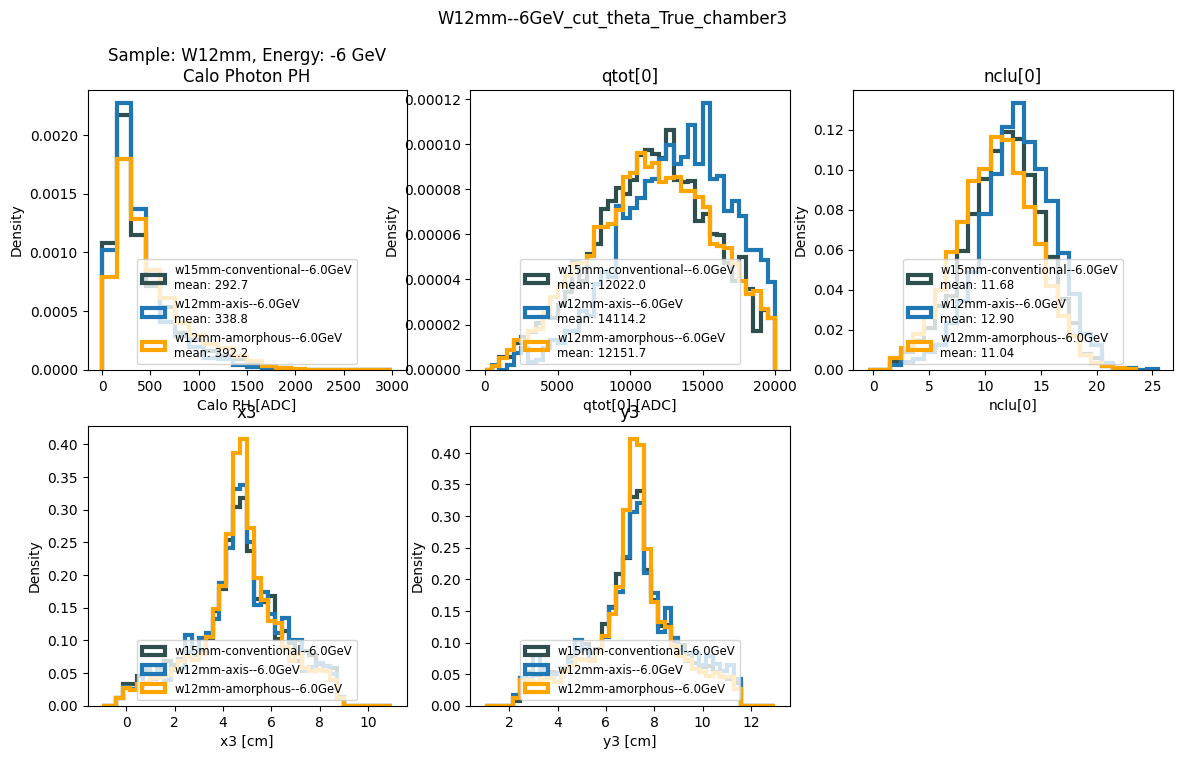

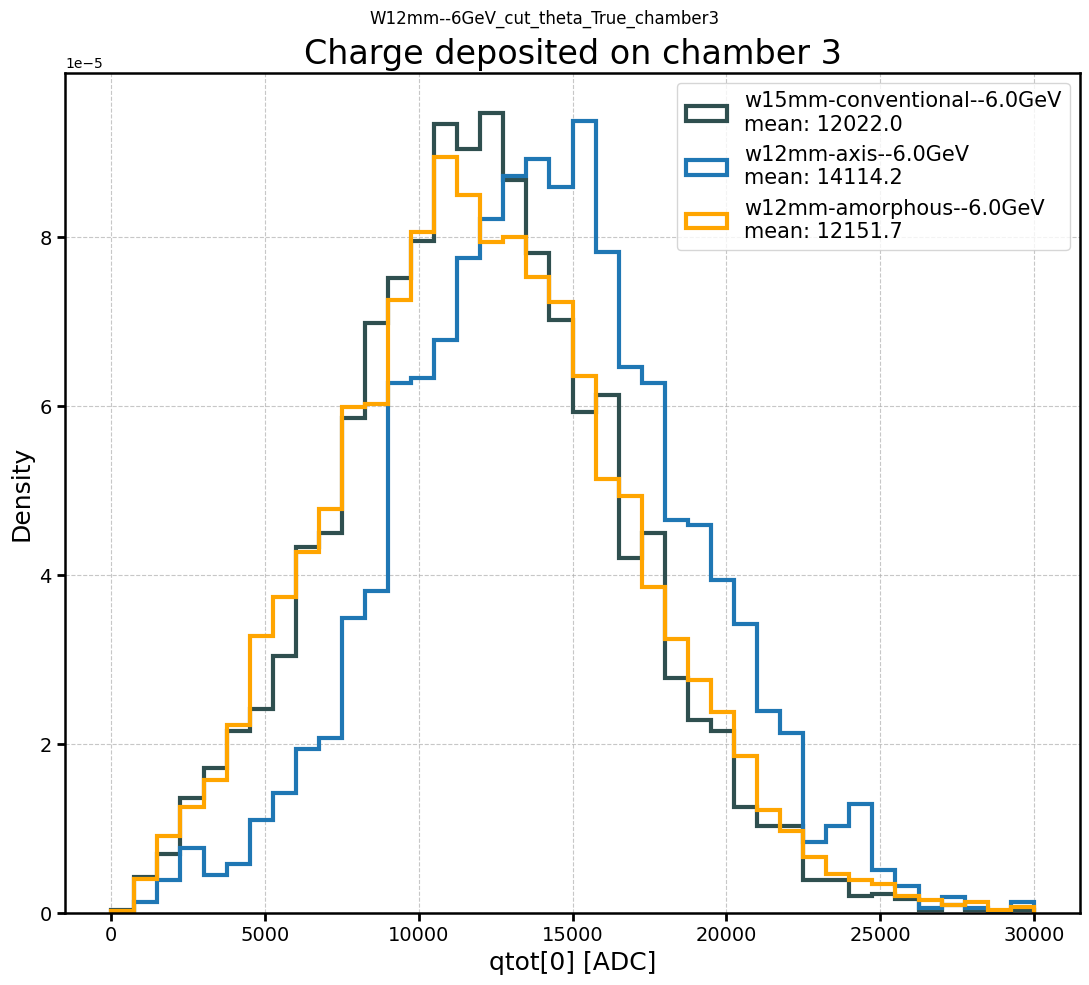

In [5]:
opt_hist = dict(histtype='step', linewidth=3)

fig, axs = plt.subplots(2, 3, figsize=(14, 8), sharey=False)
fig.suptitle(f'{target_sample}-{target_energy}GeV_cut_theta_{CutTheta}_chamber3')
axs = axs.flatten()
fig2, axs2 = plt.subplots(1, figsize=(11, 10))
fig2.suptitle(f'{target_sample}-{target_energy}GeV_cut_theta_{CutTheta}_chamber3')

means_nclu3 = {}
means_qtot3 = {}
events = {}
for j, (typ, run_list) in enumerate(group_by_type.items()):
    ref_run = run_list[0]
    label = f"{samples[ref_run]}-{typ}-{energies[ref_run]}GeV"

    # === Load all runs in the group ===
    (xpos, x1, y1, x2, y2, x3, y3, xcry, ycry, ph_calo_photon, ph_cherry1,
     theta_x_in, theta_y_in, theta_x_out, theta_y_out, tm, qtot, nclu,
     info_plus, xinfo) = file_loader(run_list)

    # === Get cuts ===
    x_cry_cut = run_config[str(ref_run)]["x_cry_cut"]
    y_cry_cut = run_config[str(ref_run)]["y_cry_cut"]
    theta_cut = theta_cut_dict[ref_run]
    # === Selection mask ===
    logi = (
        (ph_cherry1 > th_cherry1) &
        (xcry > x_cry_cut[0]) & (xcry < x_cry_cut[1]) &
        (ycry > y_cry_cut[0]) & (ycry < y_cry_cut[1]) &
        ((theta_x_in**2 + theta_y_in**2) < (theta_cut**2))
    )
    events[label] = np.sum(logi)
    logi = logi &  (nclu[:,0]>1)
    logi_calo = ph_calo_photon > 100
    if np.sum(logi) == 0:
        continue

    color = get_color(typ)
   
    axs[0].hist(ph_calo_photon[logi & logi_calo], bins=20, range=(0, 3000),
                label=f'{label}\nmean: {np.mean(ph_calo_photon[logi]):.1f}', density=True,
                color=color, **opt_hist)
    axs[1].hist(qtot[:, 0][logi], bins=40, range=(0, 20000),
                label=f'{label}\nmean: {np.mean(qtot[:, 0][logi]):.1f}', density=True,
                color=color, **opt_hist)
    axs[2].hist(nclu[:, 0][logi], bins=np.arange(-0.5, np.max(nclu[:, 0]) + 0.5, 1),
                label=f'{label}\nmean: {np.mean(nclu[:, 0][logi]):.2f}', density=True,
                color=color, **opt_hist)
    axs[3].hist(x3[logi], bins=42, range=(-1, 11), label=label, density=True,
                color=color, **opt_hist)
    axs[4].hist(y3[logi], bins=42, range=(1, 13), label=label, density=True,
                color=color, **opt_hist)

    valid = logi & (nclu[:, 0] > 0)
    means_nclu3[label] = np.mean(nclu[:, 0][valid])
    means_qtot3[label] = np.mean(qtot[:, 0][valid])
    if  np.abs(target_energy) == 2.86 :
        range_q = (0,22000)
    else:
        range_q = (0,30000)
    axs2.hist(qtot[:, 0][logi], bins=40, range=range_q,
                label=f'{label}\nmean: {np.mean(qtot[:, 0][logi]):.1f}', density=True,
                color=color, **opt_hist)


# === Titles and labels ===
axs[0].set_title(f'Sample: {target_sample}, Energy: {target_energy} GeV\nCalo Photon PH')
axs[1].set_title('qtot[0]')
axs[2].set_title('nclu[0]')
axs[3].set_title('x3')
axs[4].set_title('y3')

labels = ['Calo PH [ADC]', 'qtot[0] [ADC]', 'nclu[0]', 'x3 [cm]', 'y3 [cm]']
for j in range(5):
    axs[j].set_xlabel(labels[j])
    axs[j].set_ylabel('Density')
    axs[j].legend(fontsize='small', loc='lower center')
    # axs[j].set_yscale('log')  # scommenta se vuoi scala log

## === Styling for axs2 ===
axs2.set_title('Charge deposited on chamber 3', fontsize=24)
axs2.set_xlabel('qtot[0] [ADC]', fontsize=18)
axs2.set_ylabel('Density', fontsize=18)
axs2.tick_params(axis='both', which='major', labelsize=14, width=2, length=6)
axs2.tick_params(axis='both', which='minor', labelsize=12, width=1.5, length=4)
axs2.grid(True, linestyle='--', linewidth=0.8, alpha=0.7)
axs2.spines['top'].set_linewidth(1.8)
axs2.spines['right'].set_linewidth(1.8)
axs2.spines['left'].set_linewidth(1.8)
axs2.spines['bottom'].set_linewidth(1.8)
axs2.legend(fontsize=15, loc='best')
axs[5].axis('off')  # Subplot vuoto disattivato


fig.savefig(f'./figures/{target_sample}-{target_energy}GeV_cut_theta_{CutTheta}_chamber3.png',dpi = 100)
fig2.savefig(f'./figures/{target_sample}-{target_energy}GeV_cut_theta_{CutTheta}_chamber3_Conv_{ifConventional}_Amorph_{ifAmorphous}.png',dpi = 100)
plt.tight_layout()
plt.show()


In [6]:
import pandas as pd
import os

# === IMPOSTAZIONI ===
csv_path = "./results_summary.csv"
config_key = f'{target_sample}-{target_energy}GeV_cut_theta_{CutTheta}'

# === FUNZIONE PER IL CALCOLO SICURO DEI RAPPORTI ===
def safe_ratio(numerator_label, denominator_label, data_dict, name):
    if numerator_label in data_dict and denominator_label in data_dict:
        ratio = 100 * data_dict[numerator_label] / data_dict[denominator_label]
        print(f"{name} = {ratio:.2f}%")
        return round(ratio, 2)
    return None

# === TROVA LABEL CANONICI ===
axis_label, amorph_label, conv_label = None, None, None

for typ, run_list in group_by_type.items():
    ref_run = run_list[0]
    if energies[ref_run] != target_energy:
        continue

    label = f"{samples[ref_run]}-{typ}-{energies[ref_run]}GeV"
    canonical = canonical_type(types[ref_run])
    
    if canonical == "Axis":
        axis_label = label
    elif canonical == "Amorphous":
        amorph_label = label
    elif canonical in ["Conventional", "Transition"]:
        conv_label = label

# === STAMPA E CREA RIGA ===
print(f"--- Energy: {target_energy} GeV ---")
row = {
    "Config": config_key,
    "NCLU_ch3 Axis / Amorphous [%]": safe_ratio(axis_label, amorph_label, means_nclu3, "NCLU_ch3 Axis / Amorphous"),
    "QTOT_ch3 Axis / Amorphous [%]": safe_ratio(axis_label, amorph_label, means_qtot3, "QTOT_ch3 Axis / Amorphous"),
    
    "NCLU_ch3 Axis / Conventional [%]": safe_ratio(axis_label, conv_label, means_nclu3, "NCLU_ch3 Axis / Conventional"),
    "QTOT_ch3 Axis / Conventional [%]": safe_ratio(axis_label, conv_label, means_qtot3, "QTOT_ch3 Axis / Conventional"),
    
    "NCLU_ch3 Amorphous / Conventional [%]": safe_ratio(amorph_label, conv_label, means_nclu3, "NCLU_ch3 Amorphous / Conventional"),
    "QTOT_ch3 Amorphous / Conventional [%]": safe_ratio(amorph_label, conv_label, means_qtot3, "QTOT_ch3 Amorphous / Conventional")
}
print()

# === Salvataggio intelligente: aggiorna solo le colonne nuove per stessa Config ===
df_new = pd.DataFrame([row])

if os.path.exists(csv_path):
    df_all = pd.read_csv(csv_path)

    if row["Config"] in df_all["Config"].values:
        # Trova l'indice della riga esistente
        idx = df_all[df_all["Config"] == row["Config"]].index[0]

        # Aggiorna solo le nuove colonne
        for col, val in row.items():
            if col != "Config":
                df_all.at[idx, col] = val
    else:
        # Config non presente: aggiungi riga nuova
        df_all = pd.concat([df_all, df_new], ignore_index=True)
else:
    df_all = df_new

df_all.to_csv(csv_path, index=False)
print(f"✅ Dati aggiornati in {csv_path}")


--- Energy: -6 GeV ---
NCLU_ch3 Axis / Amorphous = 116.85%
QTOT_ch3 Axis / Amorphous = 116.15%
NCLU_ch3 Axis / Conventional = 110.45%
QTOT_ch3 Axis / Conventional = 117.40%
NCLU_ch3 Amorphous / Conventional = 94.52%
QTOT_ch3 Amorphous / Conventional = 101.08%

✅ Dati aggiornati in ./results_summary.csv


Run 730247 — N spill: 710 — events: 76622 — evs/spill: 108
[730247] — TOTAL SPILLS: 710 — TOTAL EVENTS: 75721
Run 730245 — N spill: 2860 — events: 274725 — evs/spill: 96
[730245] — TOTAL SPILLS: 2860 — TOTAL EVENTS: 271623
Run 730224 — N spill: 1334 — events: 194507 — evs/spill: 146
[730224] — TOTAL SPILLS: 1334 — TOTAL EVENTS: 192340


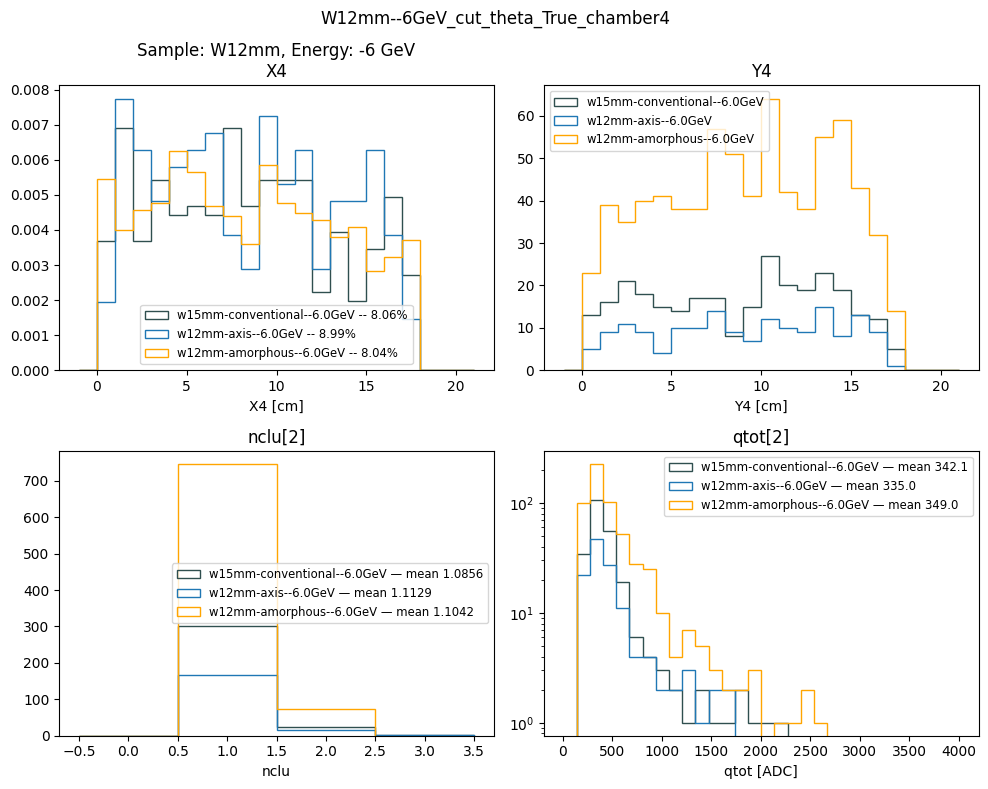

In [7]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle(f'{target_sample}-{target_energy}GeV_cut_theta_{CutTheta}_chamber4')
ax = ax.flatten()
iWantDensity = False

means_nclu4 = {}
means_qtot4 = {}

for typ, run_list in group_by_type.items():
    ref_run = run_list[0]
    label = f"{samples[ref_run]}-{typ}-{energies[ref_run]}GeV"

    # === Load data (tutti i run)
    (xpos, x1, y1, x2, y2, x3, y3, xcry, ycry, ph_calo_photon, ph_cherry1,
     theta_x_in, theta_y_in, theta_x_out, theta_y_out, tm, qtot, nclu,
     info_plus, xinfo) = file_loader(run_list)

    # === Get cuts from config
    x_cry_cut = run_config[str(ref_run)]["x_cry_cut"]
    y_cry_cut = run_config[str(ref_run)]["y_cry_cut"]
    theta_cut = theta_cut_dict[ref_run]

    # === Selection mask
    mask = (
        (ph_cherry1 > th_cherry1) &
        (xcry > x_cry_cut[0]) & (xcry < x_cry_cut[1]) &
        (ycry > y_cry_cut[0]) & (ycry < y_cry_cut[1]) &
        ((theta_x_in**2 + theta_y_in**2) < (theta_cut**2)) &
        (nclu[:,0]>1) & 
        (nclu[:, 2] > 0)
    )

    # === Detector 4: x4, y4 ===
    x4 = xpos[:, 6]
    y4 = xpos[:, 7]
    color = get_color(label)
    
    ax[0].hist(x4[mask], bins=22, range=(-1, 21),color=color,weights=1/events[label]*np.ones_like(x4[mask]), histtype='step', density=iWantDensity, label=label + f' -- {100* (np.sum(mask)/events[label]):.2f}%')
    ax[1].hist(y4[mask], bins=22, range=(-1, 21),color=color, histtype='step', density=iWantDensity, label=label)
    ax[2].hist(nclu[:, 2][mask], bins=np.arange(-0.5, round(np.max(nclu[:, 2])) + 0.5, 1),color=color,
               histtype='step', density=iWantDensity, label=f'{label} — mean {np.mean(nclu[:, 2][mask]):.4f}')
    ax[3].hist(qtot[:, 2][mask], bins=30, range=(10, 4000),color=color, histtype='step', density=iWantDensity,
               label=f'{label} — mean {np.mean(qtot[:, 2][mask]):.1f}')

    means_nclu4[label] = np.mean(nclu[:, 2][mask])
    means_qtot4[label] = np.mean(qtot[:, 2][mask])

# === Axis formatting ===
ax[0].set_title(f'Sample: {target_sample}, Energy: {target_energy} GeV\nX4')
ax[1].set_title('Y4')
ax[2].set_title('nclu[2]')
ax[3].set_title('qtot[2]')
ax[0].set_xlabel('X4 [cm]')
ax[1].set_xlabel('Y4 [cm]')
ax[2].set_xlabel('nclu')
ax[3].set_xlabel('qtot [ADC]')
ax[3].set_yscale('log')

for a in ax:
    a.legend(fontsize='small')
fig.savefig(f'./figures/{target_sample}-{target_energy}GeV_cut_theta_{CutTheta}_chamber4.png',dpi = 100)
plt.tight_layout()
plt.show()



In [8]:
# === Calcola e salva rapporti per chamber 4 ===

# === Trova i label canonici ===
axis_label, amorph_label, conv_label = None, None, None

for typ, run_list in group_by_type.items():
    ref_run = run_list[0]
    if energies[ref_run] != target_energy:
        continue

    label = f"{samples[ref_run]}-{typ}-{energies[ref_run]}GeV"
    canonical = canonical_type(types[ref_run])
    
    if canonical == "Axis":
        axis_label = label
    elif canonical == "Amorphous":
        amorph_label = label
    elif canonical in ["Conventional", "Transition"]:
        conv_label = label

# === Stampa e costruisci nuova riga ===
print(f"--- Energy: {target_energy} GeV (Chamber 4) ---")
row = {
    "Config": f'{target_sample}-{target_energy}GeV_cut_theta_{CutTheta}',
    "NCLU_x4 Axis / Amorphous [%]": safe_ratio(axis_label, amorph_label, means_nclu4, "NCLU_x4 Axis / Amorphous"),
    "QTOT_x4 Axis / Amorphous [%]": safe_ratio(axis_label, amorph_label, means_qtot4, "QTOT_x4 Axis / Amorphous"),
    
    "NCLU_x4 Axis / Conventional [%]": safe_ratio(axis_label, conv_label, means_nclu4, "NCLU_x4 Axis / Conventional"),
    "QTOT_x4 Axis / Conventional [%]": safe_ratio(axis_label, conv_label, means_qtot4, "QTOT_x4 Axis / Conventional"),
    
    "NCLU_x4 Amorphous / Conventional [%]": safe_ratio(amorph_label, conv_label, means_nclu4, "NCLU_x4 Amorphous / Conventional"),
    "QTOT_x4 Amorphous / Conventional [%]": safe_ratio(amorph_label, conv_label, means_qtot4, "QTOT_x4 Amorphous / Conventional")
}
print()

# === Salvataggio intelligente: aggiorna solo le colonne nuove per stessa Config ===
df_new = pd.DataFrame([row])

if os.path.exists(csv_path):
    df_all = pd.read_csv(csv_path)

    if row["Config"] in df_all["Config"].values:
        # Trova l'indice della riga esistente
        idx = df_all[df_all["Config"] == row["Config"]].index[0]

        # Aggiorna solo le nuove colonne
        for col, val in row.items():
            if col != "Config":
                df_all.at[idx, col] = val
    else:
        # Config non presente: aggiungi riga nuova
        df_all = pd.concat([df_all, df_new], ignore_index=True)
else:
    df_all = df_new

df_all.to_csv(csv_path, index=False)
print(f"✅ Dati aggiornati in {csv_path}")


--- Energy: -6 GeV (Chamber 4) ---
NCLU_x4 Axis / Amorphous = 100.78%
QTOT_x4 Axis / Amorphous = 95.98%
NCLU_x4 Axis / Conventional = 102.51%
QTOT_x4 Axis / Conventional = 97.93%
NCLU_x4 Amorphous / Conventional = 101.71%
QTOT_x4 Amorphous / Conventional = 102.03%

✅ Dati aggiornati in ./results_summary.csv
